# Signal Types Classification

## Кластеризация сигналов сцинтилляционного детектора

Цель: разделить 23 479 сигналов на три кластера:
- кластер 0 — сигналы первого типа частиц,
- кластер 1 — сигналы второго типа частиц,
- кластер 2 — аномальные, смешанные или плохо классифицируемые сигналы.

## 1. Импорт библиотек

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)

## 2. Загрузка и структура данных

In [2]:
from google.colab import drive

drive.mount("/content/drive")

data_path = Path(
    "/content/drive/MyDrive/Signal_types_classification/Run200_Wave_0_1.txt"
)

raw = pd.read_csv(
    data_path,
    sep=r"\s+",
    header=None,
    dtype=np.int64,
)

meta = raw.iloc[:, :4].copy()
signals = raw.iloc[:, 4:].astype(np.float32)

print("Файл:", data_path)
print("Размер исходной таблицы:", raw.shape)
print("Количество сигналов:", len(signals))
print("Количество отсчётов в одном сигнале:", signals.shape[1])
print("Количество пропусков:", int(raw.isna().sum().sum()))

Mounted at /content/drive
Файл: /content/drive/MyDrive/Signal_types_classification/Run200_Wave_0_1.txt
Размер исходной таблицы: (23479, 504)
Количество сигналов: 23479
Количество отсчётов в одном сигнале: 500
Количество пропусков: 0


В каждой строке присутствуют четыре служебных значения и далее 500 временных отсчётов сигнала. Четвёртое служебное поле равно 500 для всех строк, поэтому не содержит информации для кластеризации и не используется как признак.

Константные и служебные признаки не должны влиять на геометрию кластеров - это важный этап EDA.

In [3]:
meta_summary = pd.DataFrame({
    "min": meta.min(),
    "median": meta.median(),
    "max": meta.max(),
    "n_unique": meta.nunique(),
})
display(meta_summary)

constant_meta = meta.columns[meta.nunique() == 1].tolist()
print("Константные служебные столбцы:", constant_meta)

,min,median,max,n_unique
0,2890276,1.014553e+11,200010687656,23479
1,0,8.100000e+02,1998,276
2,10,1.720000e+02,3370,2079
3,500,5.000000e+02,500,1


Константные служебные столбцы: [3]


## 3. EDA: форма и статистика сигналов

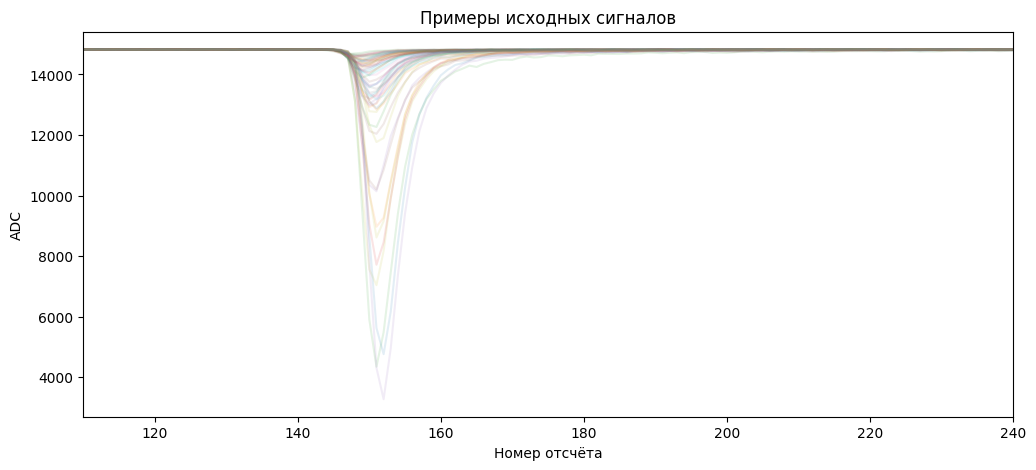

In [4]:
plt.figure(figsize=(12, 5))

for idx in range(60):
    plt.plot(signals.iloc[idx].to_numpy(), alpha=0.12)

plt.xlim(110, 240)
plt.xlabel("Номер отсчёта")
plt.ylabel("ADC")
plt.title("Примеры исходных сигналов")
plt.show()

Видно, что импульсы направлены вниз относительно baseline. Поэтому для дальнейшего анализа сигнал инвертируется относительно оценки базовой линии. Основной импульс расположен примерно в одной временной области, а различия между событиями проявляются в амплитуде и скорости спада.

In [5]:
x_raw = signals.to_numpy(dtype=np.float32)

# Baseline оценивается по области до импульса
baseline = x_raw[:, :120].mean(axis=1, keepdims=True)

# Инверсия относительно baseline
# Отрицательные шумовые флуктуации здесь намеренно не обрезаются,
# т. к. это уменьшает смещение интегральных PSD-признаков
pulse = baseline - x_raw

peak_idx = pulse.argmax(axis=1)
max_amp = pulse.max(axis=1)

width50 = np.zeros(len(pulse), dtype=np.int32)

for row_id, row in enumerate(pulse):
    above_half = np.where(row >= 0.5 * max_amp[row_id])[0]
    width50[row_id] = (
        int(above_half[-1] - above_half[0])
        if len(above_half)
        else 0
    )

total_area = pulse[:, 145:350].sum(axis=1)
log_energy = np.log1p(np.maximum(total_area, 1))

signal_stats = pd.DataFrame({
    "baseline": baseline.ravel(),
    "max_amp": max_amp,
    "peak_idx": peak_idx,
    "width50": width50,
    "total_area": total_area,
    "log_energy": log_energy,
})

display(
    signal_stats.quantile(
        [0.00, 0.01, 0.25, 0.50, 0.75, 0.99, 1.00]
    ).T
)

,0.00,0.01,0.25,0.50,0.75,0.99,1.00
baseline,14818.941406,14821.056660,14822.416992,14822.958008,14823.508789,14824.866211,14826.108398
max_amp,104.200195,121.398457,308.275391,812.750000,2315.278809,11066.887754,14824.691406
peak_idx,145.000000,146.000000,149.000000,150.000000,151.000000,152.000000,472.000000
width50,2.000000,3.000000,4.000000,4.000000,5.000000,6.000000,326.000000
total_area,465.141602,774.399141,2396.544922,6129.790039,17030.568359,72320.987500,112411.000000
log_energy,6.144489,6.653378,7.782201,8.721079,9.742824,11.188884,11.629926


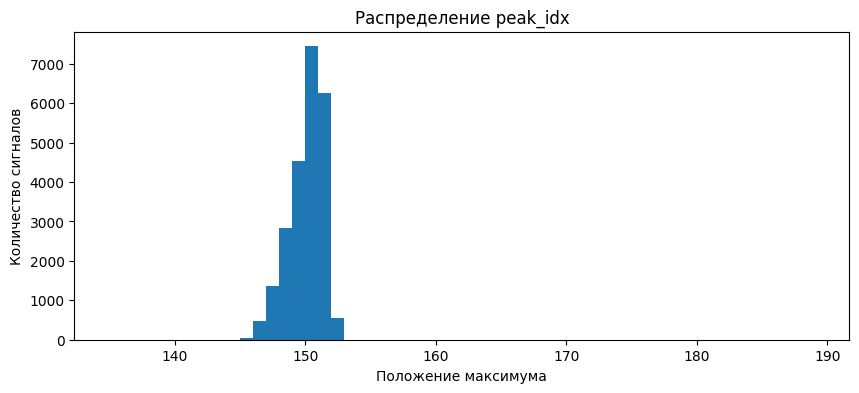

Доля сигналов с максимумом в диапазоне [145, 155]: 1.0000


In [6]:
plt.figure(figsize=(10, 4))
plt.hist(peak_idx, bins=np.arange(135, 190, 1))
plt.xlabel("Положение максимума")
plt.ylabel("Количество сигналов")
plt.title("Распределение peak_idx")
plt.show()

central_peak_share = np.mean((peak_idx >= 145) & (peak_idx <= 155))

print(
    "Доля сигналов с максимумом в диапазоне [145, 155]:",
    f"{central_peak_share:.4f}",
)

Вывод по EDA: подавляющее большинство импульсов синхронизировано по времени. Поэтому события с сильно смещённым максимумом или аномально большой шириной можно интерпретировать как явные выбросы формы. При этом для разделения двух основных типов важнее не энергия, а относительная форма хвоста.

## 4. Feature Engineering: Pulse Shape Discrimination

Для органических сцинтилляторов полезным признаком является доля поздней компоненты импульса:

\[
PSD = \frac{Q_{tail}}{Q_{total}}.
\]

Положение начала хвостового окна не задаётся произвольно. Оно выбирается автоматически: на высоком SNR для нескольких кандидатов обучается двухкомпонентная GMM, после чего выбирается окно с максимальным разделением компонент в единицах стандартного отклонения.

In [7]:
total_start = 145
total_end = 350

candidate_tail_starts = [
    156, 157, 158, 159, 160, 161,
    162, 165, 170, 175, 180, 190,
]

high_snr = (
    (log_energy > 9.0)
    & (peak_idx >= 145)
    & (peak_idx <= 155)
)

window_results = []

for tail_start in candidate_tail_starts:
    psd_candidate = (
        pulse[:, tail_start:total_end].sum(axis=1)
        / (total_area + 1e-9)
    )

    model = GaussianMixture(
        n_components=2,
        n_init=20,
        random_state=RANDOM_STATE,
        reg_covar=1e-6,
    )
    model.fit(psd_candidate[high_snr, None])

    order = np.argsort(model.means_.ravel())
    means = model.means_.ravel()[order]
    sigmas = np.sqrt(model.covariances_.ravel()[order])

    separation = (
        (means[1] - means[0])
        / np.sqrt(np.mean(sigmas ** 2))
    )

    window_results.append({
        "tail_start": tail_start,
        "separation_sigma": separation,
        "mean_low": means[0],
        "mean_high": means[1],
    })

window_results = pd.DataFrame(window_results)
window_results = window_results.sort_values(
    "separation_sigma",
    ascending=False,
)

display(window_results)

best_tail_start = int(window_results.iloc[0]["tail_start"])
print("Автоматически выбранное начало tail-окна:", best_tail_start)

,tail_start,separation_sigma,mean_low,mean_high
3,159,8.584229,0.125350,0.268417
2,158,8.520410,0.144736,0.290255
4,160,8.517741,0.110765,0.250630
5,161,8.406112,0.099566,0.235870
6,162,8.307043,0.090707,0.223301
1,157,8.194386,0.170877,0.317541
7,165,8.028203,0.072229,0.194273
8,170,7.699963,0.055866,0.162665
9,175,7.438868,0.046643,0.141359
0,156,7.360196,0.206543,0.352191


Автоматически выбранное начало tail-окна: 159


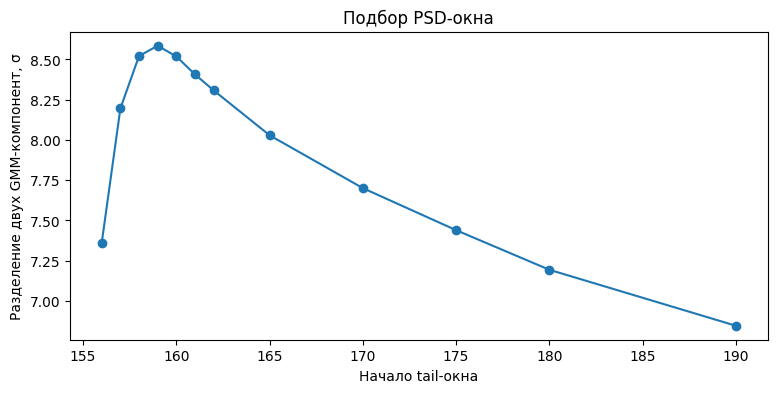

In [8]:
ordered_windows = window_results.sort_values("tail_start")

plt.figure(figsize=(9, 4))
plt.plot(
    ordered_windows["tail_start"],
    ordered_windows["separation_sigma"],
    marker="o",
)
plt.xlabel("Начало tail-окна")
plt.ylabel("Разделение двух GMM-компонент, σ")
plt.title("Подбор PSD-окна")
plt.show()

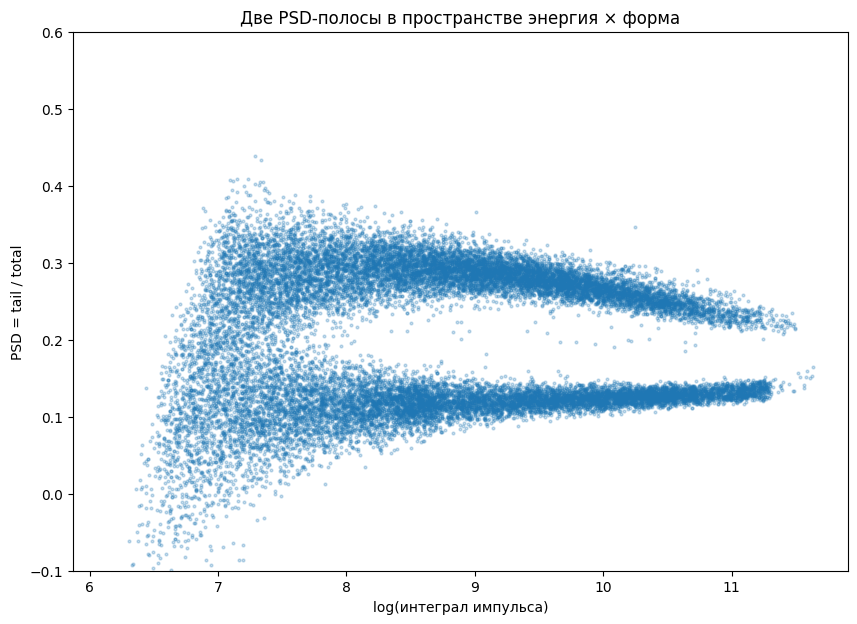

In [9]:
psd_ratio = (
    pulse[:, best_tail_start:total_end].sum(axis=1)
    / (total_area + 1e-9)
)

plt.figure(figsize=(10, 7))
plt.scatter(
    log_energy,
    psd_ratio,
    s=4,
    alpha=0.25,
)
plt.xlabel("log(интеграл импульса)")
plt.ylabel("PSD = tail / total")
plt.title("Две PSD-полосы в пространстве энергия × форма")
plt.ylim(-0.1, 0.6)
plt.show()

На диаграмме наблюдаются две выраженные полосы. Это ключевая закономерность, упрощающая задачу: вместо кластеризации сотен временных отсчётов можно перейти к физически интерпретируемому двумерному представлению "энергия × форма импульса".

## 5. Сравнение моделей и гиперпараметров

In [10]:
model_features = np.column_stack([
    log_energy,
    psd_ratio,
    peak_idx,
    width50,
])

scaled_features = StandardScaler().fit_transform(model_features)

models = {
    "KMeans_ninit20": KMeans(
        n_clusters=3,
        n_init=20,
        random_state=RANDOM_STATE,
    ),
    "KMeans_ninit100": KMeans(
        n_clusters=3,
        n_init=100,
        random_state=RANDOM_STATE,
    ),
    "MiniBatchKMeans": MiniBatchKMeans(
        n_clusters=3,
        batch_size=2048,
        n_init=50,
        random_state=RANDOM_STATE,
    ),
    "GMM_full": GaussianMixture(
        n_components=3,
        covariance_type="full",
        n_init=20,
        random_state=RANDOM_STATE,
    ),
    "GMM_diag": GaussianMixture(
        n_components=3,
        covariance_type="diag",
        n_init=20,
        random_state=RANDOM_STATE,
    ),
}

comparison_rows = []

for model_name, model in models.items():
    labels_candidate = model.fit_predict(scaled_features)

    comparison_rows.append({
        "model": model_name,
        "silhouette": silhouette_score(
            scaled_features,
            labels_candidate,
            sample_size=5000,
            random_state=RANDOM_STATE,
        ),
        "calinski_harabasz": calinski_harabasz_score(
            scaled_features,
            labels_candidate,
        ),
        "davies_bouldin": davies_bouldin_score(
            scaled_features,
            labels_candidate,
        ),
        "cluster_sizes": str(
            pd.Series(labels_candidate)
            .value_counts()
            .sort_index()
            .to_dict()
        ),
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison.sort_values("silhouette", ascending=False))

,model,silhouette,calinski_harabasz,davies_bouldin,cluster_sizes
2,MiniBatchKMeans,0.414815,7174.191957,0.830838,"{0: 7458, 1: 9044, 2: 6977}"
1,KMeans_ninit100,0.339879,19453.617691,0.833959,"{0: 11446, 1: 12032, 2: 1}"
0,KMeans_ninit20,0.339676,19453.215422,0.833663,"{0: 11562, 1: 1, 2: 11916}"
4,GMM_diag,0.328514,18789.898989,0.858462,"{0: 9971, 1: 1, 2: 13507}"
3,GMM_full,0.315760,4630.558695,1.049094,"{0: 11618, 1: 3250, 2: 8611}"


### Вывод по моделям

KMeans и обычная глобальная GMM полезны как baseline, но их геометрические предположения не полностью соответствуют данным. Две физические группы образуют изогнутые полосы, их положение зависит от энергии. Значит, высокая внутренняя метрика сама по себе не является достаточным критерием, т. к. модель может получить компактные кластеры, разделяя сигналы преимущественно по амплитуде.

## 6. Финальная модель: условная 2-GMM

In [11]:
# Строгий критерий для отдельного кластера явных аномалий формы
base_anomaly = (
    (peak_idx < 145)
    | (peak_idx > 155)
    | (width50 > 20)
)

normal_mask = (
    (~base_anomaly)
    & np.isfinite(log_energy)
    & np.isfinite(psd_ratio)
    & (total_area > 100)
)

# Равные по числу объектов энергетические интервалы
energy_edges = np.unique(
    np.quantile(
        log_energy[normal_mask],
        np.linspace(0, 1, 31),
    )
)

band_rows = []

for bin_id, (left, right) in enumerate(
    zip(energy_edges[:-1], energy_edges[1:])
):
    is_last = bin_id == len(energy_edges) - 2

    if is_last:
        in_bin = (
            normal_mask
            & (log_energy >= left)
            & (log_energy <= right)
        )
    else:
        in_bin = (
            normal_mask
            & (log_energy >= left)
            & (log_energy < right)
        )

    values = psd_ratio[in_bin]

    if len(values) < 100:
        continue

    gmm = GaussianMixture(
        n_components=2,
        n_init=20,
        random_state=RANDOM_STATE,
        reg_covar=1e-5,
    )
    gmm.fit(values[:, None])

    order = np.argsort(gmm.means_.ravel())
    means = gmm.means_.ravel()[order]
    sigmas = np.sqrt(gmm.covariances_.ravel()[order])
    weights = gmm.weights_.ravel()[order]

    def log_density_difference(value):
        first = (
            np.log(weights[0] + 1e-12)
            - np.log(sigmas[0])
            - 0.5
            * ((value - means[0]) / sigmas[0]) ** 2
        )
        second = (
            np.log(weights[1] + 1e-12)
            - np.log(sigmas[1])
            - 0.5
            * ((value - means[1]) / sigmas[1]) ** 2
        )
        return first - second

    grid = np.linspace(means[0], means[1], 250)
    differences = np.array(
        [log_density_difference(value) for value in grid]
    )

    roots = []

    for x1, x2, y1, y2 in zip(
        grid[:-1],
        grid[1:],
        differences[:-1],
        differences[1:],
    ):
        if y1 == 0 or y1 * y2 < 0:
            try:
                roots.append(
                    brentq(
                        log_density_difference,
                        x1,
                        x2,
                    )
                )
            except ValueError:
                pass

    threshold = (
        roots[0]
        if roots
        else float((means[0] + means[1]) / 2)
    )

    separation = (
        (means[1] - means[0])
        / np.sqrt(np.mean(sigmas ** 2))
    )

    band_rows.append({
        "energy": float(np.median(log_energy[in_bin])),
        "n": int(in_bin.sum()),
        "mu_low": float(means[0]),
        "mu_high": float(means[1]),
        "sigma_low": float(sigmas[0]),
        "sigma_high": float(sigmas[1]),
        "threshold": float(threshold),
        "separation_sigma": float(separation),
    })

band_table = pd.DataFrame(band_rows)

display(band_table.head())
print(
    "Медианное разделение компонент:",
    f"{band_table['separation_sigma'].median():.3f} σ",
)

,energy,n,mu_low,mu_high,sigma_low,sigma_high,threshold,separation_sigma
0,6.724631,783,0.016074,0.122740,0.091888,0.069493,0.037034,1.309371
1,6.962556,783,0.093941,0.239479,0.062977,0.058045,0.169134,2.403163
2,7.123102,782,0.110781,0.274646,0.057575,0.052425,0.193207,2.976080
3,7.258156,783,0.108101,0.279433,0.053361,0.046263,0.194050,3.430871
4,7.390254,782,0.111768,0.279615,0.044481,0.044134,0.194139,3.788193


Медианное разделение компонент: 9.642 σ


In [12]:
threshold_spline = UnivariateSpline(
    band_table["energy"],
    band_table["threshold"],
    w=np.sqrt(band_table["n"]),
    s=0.002,
)

energy_clipped = np.clip(
    log_energy,
    band_table["energy"].min(),
    band_table["energy"].max(),
)

threshold_curve = threshold_spline(energy_clipped)

# Внутренняя нумерация:
# 0 = нижняя PSD-полоса,
# 1 = верхняя PSD-полоса,
# 2 = явные аномалии формы
labels_internal = (psd_ratio > threshold_curve).astype(np.int32)
labels_internal[base_anomaly] = 2

print("Размеры внутренних кластеров:")
print(
    pd.Series(labels_internal)
    .value_counts()
    .sort_index()
)

Размеры внутренних кластеров:
0    10989
1    12489
2        1
Name: count, dtype: int64


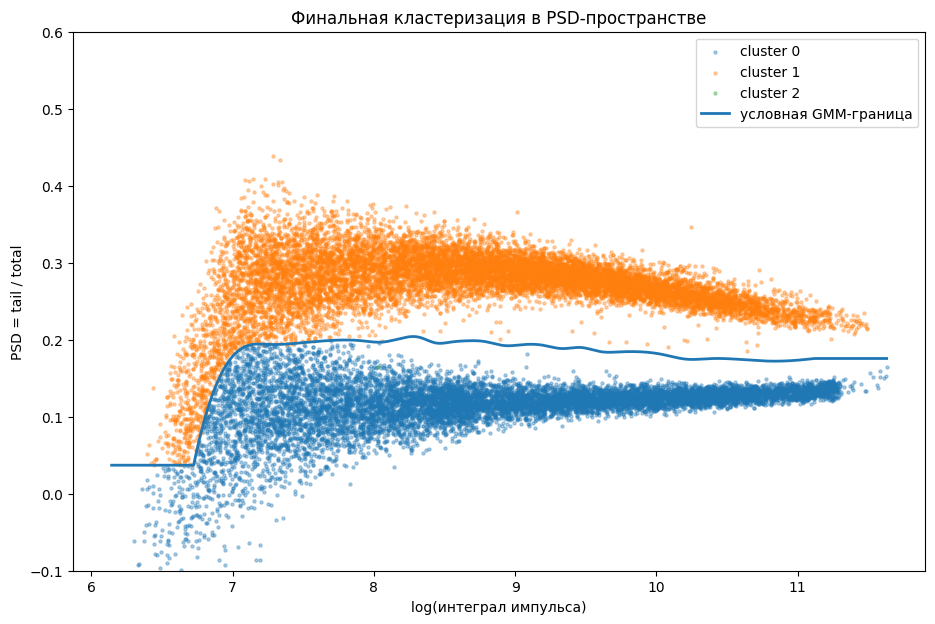

In [13]:
plt.figure(figsize=(11, 7))

for cluster_id in [0, 1, 2]:
    mask = labels_internal == cluster_id
    plt.scatter(
        log_energy[mask],
        psd_ratio[mask],
        s=5,
        alpha=0.35,
        label=f"cluster {cluster_id}",
    )

order = np.argsort(log_energy)
plt.plot(
    log_energy[order],
    threshold_curve[order],
    linewidth=2,
    label="условная GMM-граница",
)

plt.xlabel("log(интеграл импульса)")
plt.ylabel("PSD = tail / total")
plt.title("Финальная кластеризация в PSD-пространстве")
plt.ylim(-0.1, 0.6)
plt.legend()
plt.show()

## 7. Интерпретация кластеров

In [14]:
profile = pd.DataFrame({
    "cluster_internal": labels_internal,
    "log_energy": log_energy,
    "psd_ratio": psd_ratio,
    "max_amp": max_amp,
    "peak_idx": peak_idx,
    "width50": width50,
})

cluster_profile = (
    profile.groupby("cluster_internal")
    .agg(
        n=("cluster_internal", "size"),
        log_energy_median=("log_energy", "median"),
        psd_median=("psd_ratio", "median"),
        max_amp_median=("max_amp", "median"),
        peak_idx_median=("peak_idx", "median"),
        width50_median=("width50", "median"),
    )
)

display(cluster_profile)

,n,log_energy_median,psd_median,max_amp_median,peak_idx_median,width50_median
cluster_internal,,,,,,
0,10989,8.722408,0.121760,968.108398,150.0,4.0
1,12489,8.720922,0.277623,679.733398,150.0,4.0
2,1,8.030519,0.164985,819.674805,472.0,326.0


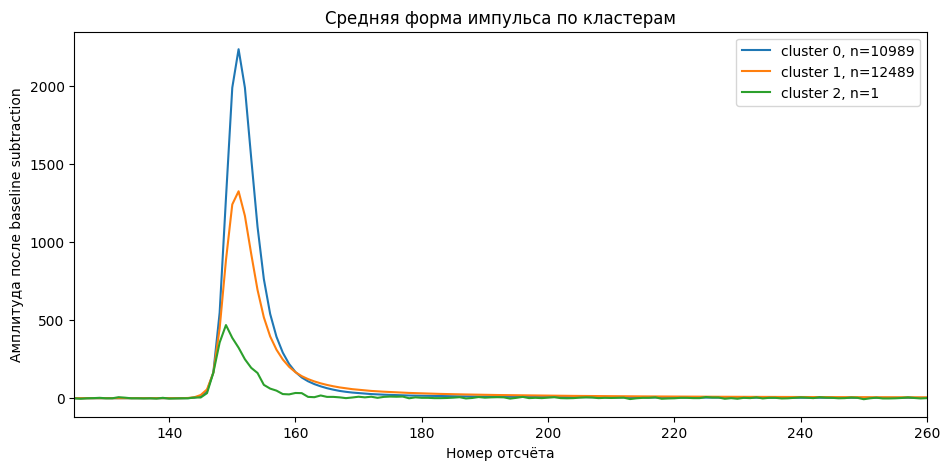

In [15]:
plt.figure(figsize=(11, 5))

x_axis = np.arange(pulse.shape[1])

for cluster_id in [0, 1, 2]:
    mask = labels_internal == cluster_id

    if mask.sum() == 0:
        continue

    mean_waveform = pulse[mask].mean(axis=0)

    plt.plot(
        x_axis,
        mean_waveform,
        label=(
            f"cluster {cluster_id}, "
            f"n={int(mask.sum())}"
        ),
    )

plt.xlim(125, 260)
plt.xlabel("Номер отсчёта")
plt.ylabel("Амплитуда после baseline subtraction")
plt.title("Средняя форма импульса по кластерам")
plt.legend()
plt.show()

Два основных кластера различаются прежде всего относительной долей поздней компоненты импульса. Это соответствует идее PSD. Третий кластер формируется только для явно нетипичной временной формы, поэтому не забирает обычные слабые события из двух физических полос.

## 8. Приведение номеров кластеров к формату Kaggle

В кластеризации у номеров кластеров нет естественного порядка. Один и тот же результат может обозначать две группы как (0, 1) или (1, 0).

После кластеризации необходимо привести номера к требуемому порядку. Для финального submission основные кластеры переставляются (0 и 1), а кластер аномалий остаётся 2. Это не меняет границу кластеризации и не переобучает модель, а только переименовывает два найденных кластера.

In [16]:
labels_final = labels_internal.copy()

labels_final[labels_internal == 0] = 1
labels_final[labels_internal == 1] = 0

print("Финальные размеры кластеров:")
print(
    pd.Series(labels_final)
    .value_counts()
    .sort_index()
)

Финальные размеры кластеров:
0    12489
1    10989
2        1
Name: count, dtype: int64


## 9. Формирование submission.csv

In [18]:
submission = pd.DataFrame({
    "index": np.arange(len(labels_final), dtype=np.int64),
    "cluster": labels_final.astype(np.int64),
})

assert submission.shape == (23479, 2)
assert submission.columns.tolist() == ["index", "cluster"]
assert submission["index"].is_unique
assert set(submission["cluster"].unique()).issubset({0, 1, 2})

submission.to_csv(
    "/content/drive/MyDrive/Signal_types_classification/submission.csv",
    index=False
)

display(submission.head())
print("Файл сохранён: submission.csv")
print("Размер:", submission.shape)

,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


Файл сохранён: submission.csv
Размер: (23479, 2)


## 10. Результат на Kaggle

Финальный вариант с перестановкой двух основных кластеров получил: accuracy = 0.82371.

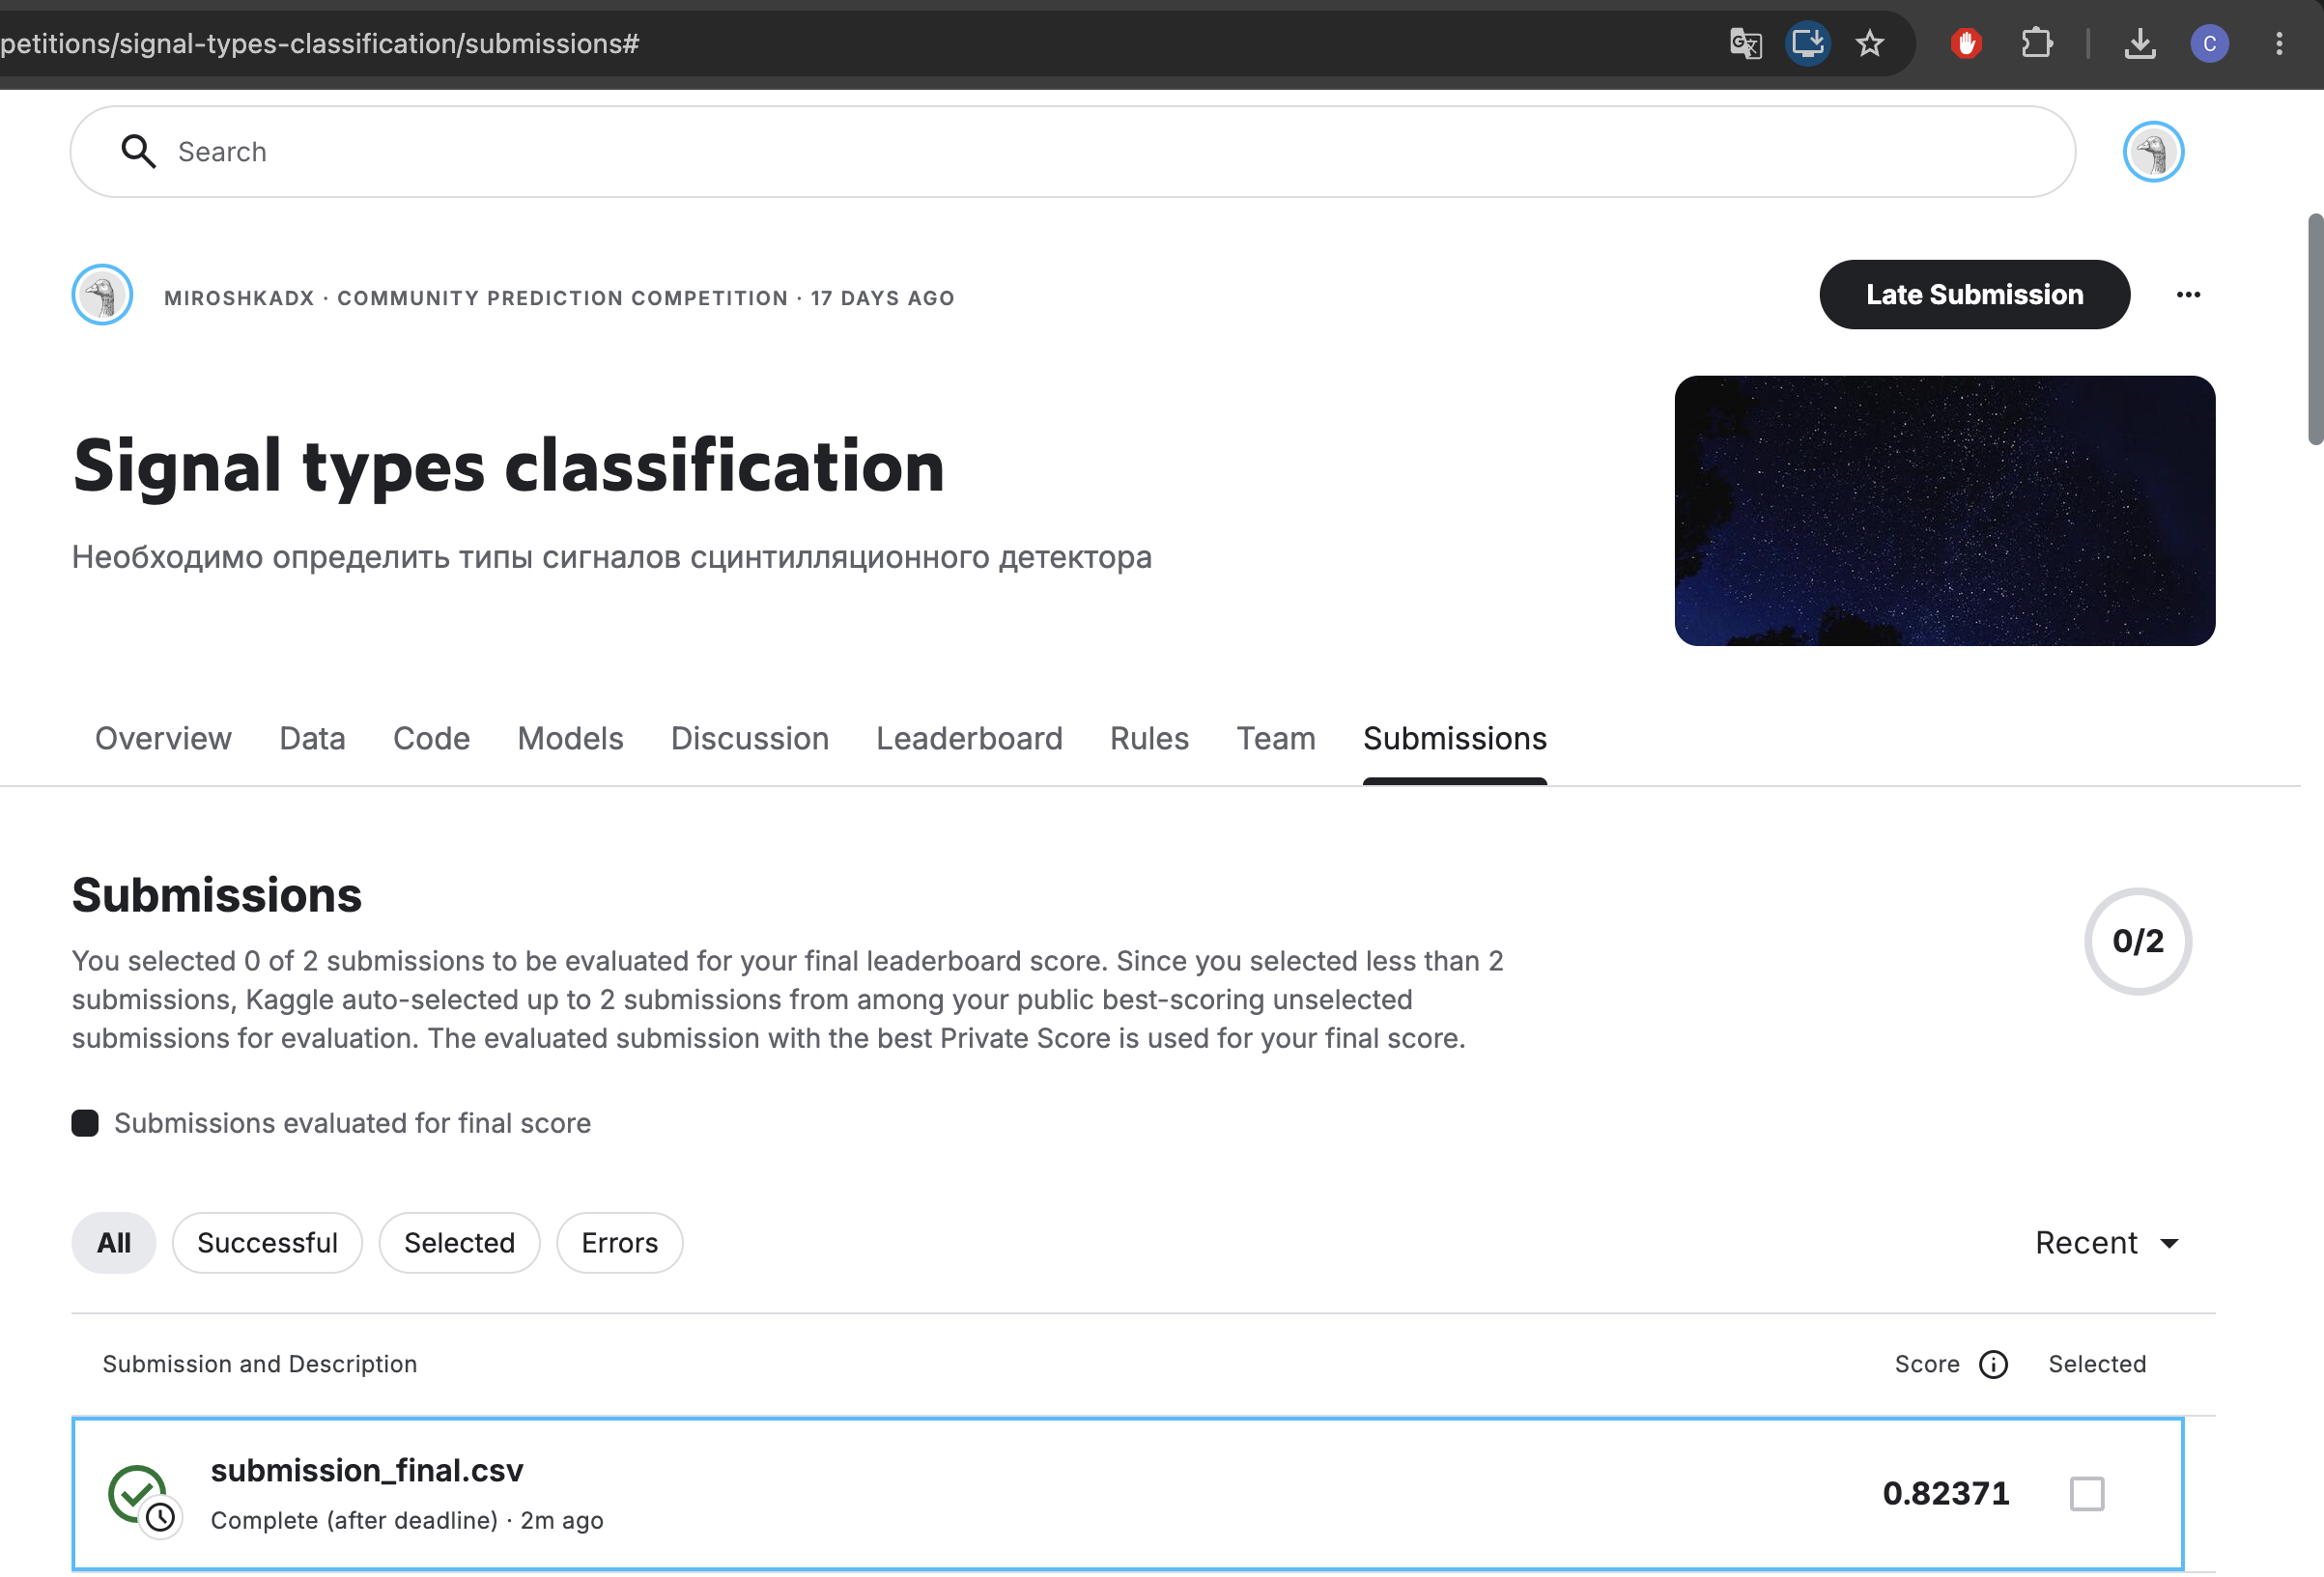

Прямой вариант без перестановки номеров кластеров давал около 0.0498, это подтверждает необходимость переименования 0 и 1.

## 11. Выводы

1. Исходный датасет содержит 23 479 сигналов по 500 временных отсчётов. Константные служебные признаки исключены из моделирования.
2. После baseline subtraction обнаружена устойчивая временная локализация импульса и две выраженные PSD-полосы.
3. Наиболее информативным оказался физически интерпретируемый признак tail/total, а начало хвоста было подобрано автоматически.
4. KMeans, MiniBatchKMeans и глобальные GMM были сравнены как baseline-модели. Их внутренние метрики не гарантируют физически корректное разделение, поскольку они могут кластеризовать преимущественно по энергии.
5. Финальная условная GMM моделирует две PSD-компоненты отдельно в энергетических интервалах и строит плавную границу между ними.
6. Явно аномальные формы выделяются в отдельный третий кластер.
7. Нумерация двух основных кластеров приведена к требуемому Kaggle-порядку простой перестановкой идентификаторов.
8. Полученный результат на Kaggle: 0.82371.